In [3]:
import os
import xml.etree.ElementTree as ET
from shutil import copytree
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
# Função para calcular a distância euclidiana
def dist_euclidiana(node1, node2):
    return np.sqrt((node1['cx'] - node2['cx'])**2 + (node1['cy'] - node2['cy'])**2)

# Função para extrair as informações principais das instâncias (id, cx e cy) - servirá de input para contruir o grafo
def extrair_nos_xml(arquivo_xml):
    tree = ET.parse(arquivo_xml)
    root = tree.getroot()
    nodes = {}

    for node in root.find('.//nodes'):
        node_id = node.get('id')
        node_type = node.get('type')
        cx = float(node.find('cx').text)
        cy = float(node.find('cy').text)

        nodes[node_id] = {
            'cx': cx,
            'cy': cy,
            'type': int(node_type)
        }

    return nodes

# Função para criar um grafo com base nos nós
# Essa função recebe como parâmetro uma lista com infos do tipo: "id": {"cx": 9.33, "cy": 59.9, "type": 0}
def grafo(nodes):
    grafo = nx.Graph()
    # node_type (0,1 ou 2, indicando se é cliente/depósito/CS) e node_coord (coordenadas do nó cx e cy)
    for node_id, node_data in nodes.items():
        grafo.add_node(node_id, pos=(node_data['cx'], node_data['cy']), type=node_data['type'])

    # Conecta todos os nós entre si com as arestas pesadas pela distância euclidiana
    node_ids = list(nodes.keys())
    for i in range(len(node_ids)):
        for j in range(i + 1, len(node_ids)):
            node_a = node_ids[i]
            node_b = node_ids[j]
            dist = dist_euclidiana(nodes[node_a], nodes[node_b])
            grafo.add_edge(node_a, node_b, weight=dist)

    return grafo

# Função para desenhar o grafo
def draw_graph(G):
    pos = nx.get_node_attributes(G, 'pos')
    node_colors = ['red' if G.nodes[node]['type'] == 0 else 'blue' if G.nodes[node]['type'] == 1 else 'green' for node in G.nodes]
    
    # Desenha os nós
    nx.draw(G, pos, node_size=500, node_color=node_colors, with_labels=True, font_weight='bold')
    
    # Desenha as arestas com os pesos
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels={k: f'{v:.2f}' for k, v in labels.items()})
    
    plt.show()

In [ ]:
def extrair_nos_xml(arquivo_xml):
    tree = ET.parse(arquivo_xml)
    root = tree.getroot()
    nodes = {}

    for node in root.find('.//nodes'):
        node_id = node.get('id')
        node_type = node.get('type')
        cx = float(node.find('cx').text)
        cy = float(node.find('cy').text)

        nodes[node_id] = {
            'cx': cx,
            'cy': cy,
            'type': int(node_type)
        }

    return nodes

In [5]:
arquivo_xml = "C:\\Users\laura\OneDrive\\Área de Trabalho\\IC - EVRP-NL-C\\instancias-evrp-nl-c\\tc2c10s3cf0-C1.xml"

In [6]:
nodes = extrair_nos_xml(arquivo_xml)
print(nodes)

{'0': {'cx': 9.33, 'cy': 59.9, 'type': 0}, '1': {'cx': 52.82, 'cy': 12.26, 'type': 1}, '2': {'cx': 55.99, 'cy': 9.57, 'type': 1}, '3': {'cx': 55.65, 'cy': 15.42, 'type': 1}, '4': {'cx': 54.55, 'cy': 16.57, 'type': 1}, '5': {'cx': 92.14, 'cy': 12.91, 'type': 1}, '6': {'cx': 92.82, 'cy': 17.12, 'type': 1}, '7': {'cx': 92.41, 'cy': 7.8, 'type': 1}, '8': {'cx': 90.68, 'cy': 17.46, 'type': 1}, '9': {'cx': 9.36, 'cy': 95.45, 'type': 1}, '10': {'cx': 11.18, 'cy': 98.14, 'type': 1}, '11': {'cx': 96.48, 'cy': 66.87, 'type': 2}, '12': {'cx': 68.25, 'cy': 66.28, 'type': 2}, '13': {'cx': 80.24, 'cy': 100.85, 'type': 2}}


In [7]:
grafos = grafo(nodes)
print(grafos)

Graph with 14 nodes and 91 edges


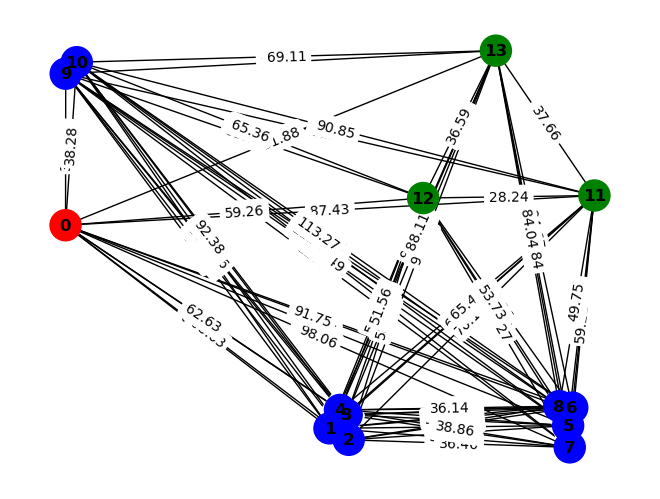

In [12]:
drawing = draw_graph(grafos)
drawing

In [16]:
# Exemplo de visualização das arestas com pesos
# for u, v, data in grafos.edges(data=True):
#     print(f"Aresta entre {u} e {v} com peso: {data['weight']:.2f}")

# # Verificando o número de conexões de cada nó
# for node_id in nodes.keys():
#     print(f"Nó {node_id} está conectado a {len(list(grafos.neighbors(node_id)))} nós.")

In [18]:
# Função para extrair o conjunto de clientes (I)
def extrair_clientes(arquivo_xml):
    clientes = []
    for node in arquivo_xml.find('network').find('nodes').findall('node'):
        node_type = int(node.get('type'))
        if node_type == 1:  # Clientes são type=1
            clientes.append(int(node.get('id')))
    return clientes

# Função para extrair estações de recarga (F)
def extrair_estacoes_recarga(arquivo_xml):
    estacoes_recarga = {}
    for node in arquivo_xml.find('network').find('nodes').findall('node'):
        node_type = int(node.get('type'))
        if node_type == 2:  # Estações de recarga são type=2
            chargers = int(node.find('custom').find('chargers').text)
            estacoes_recarga[int(node.get('id'))] = chargers
    return estacoes_recarga

# Função para extrair o tempo de serviço dos clientes e calcular o tempo total (gi e ∑gi)
def extrair_tempo_servico(arquivo_xml):
    tempo_servico = {}
    tempo_total_servico = 0
    for request in arquivo_xml.find('requests').findall('request'):
        node_id = int(request.get('node'))
        service_time = float(request.find('service_time').text)
        tempo_servico[node_id] = service_time
        tempo_total_servico += service_time
    return tempo_servico, tempo_total_servico

# Função principal para gerenciar a extração de dados
def parse_instance(arquivo_xml):
    tree = ET.parse(arquivo_xml)
    root = tree.getroot()
    clientes = extrair_clientes(root)
    estacoes_recarga = extrair_estacoes_recarga(root)
    tempo_servico, tempo_total_servico = extrair_tempo_servico(root)

    return clientes, estacoes_recarga, tempo_servico, tempo_total_servico

clientes_i, estacoes_recarga_f, tempo_servico_g, tempo_total_servico_g_tot = parse_instance(arquivo_xml)

# Exibindo os resultados
print("Conjunto de Clientes:", clientes)
print("Estações de Recarga e Número de Carregadores:", estacoes_recarga)
print("Tempo de Serviço dos Clientes:", tempo_servico)
print("Tempo Total de Serviço dos Clientes:", tempo_total_servico)

Conjunto de Clientes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Estações de Recarga e Número de Carregadores: {11: 1, 12: 1, 13: 1}
Tempo de Serviço dos Clientes: {1: 0.5, 2: 0.5, 3: 0.5, 4: 0.5, 5: 0.5, 6: 0.5, 7: 0.5, 8: 0.5, 9: 0.5, 10: 0.5}
Tempo Total de Serviço dos Clientes: 5.0


In [147]:
# Definindo variáveis arbitrárias do problema
# Capacitade da bateria dos veículos, li na internet que era entre 24 e 90 kWh
bateria_q = 57
# Consumo médio por Km rodado em kWh (carro elétrico tem consumo médio de 20 kWh para percorrer 100 km)
energia_consumo_e = 0.2
# Vou considerar velocidade média de 60km/h
velocidade_media = 60
# Definição aleatória em horas
tempo_max = 8

In [148]:
def calcular_arestas_tempo_e_energia(nodes, velocidade_media, consumo_por_km):
    arestas = {}

    node_ids = list(nodes.keys())
    for i in range(len(node_ids)):
        for j in range(i + 1, len(node_ids)):
            node_a = node_ids[i]
            node_b = node_ids[j]
            distancia = dist_euclidiana(nodes[node_a], nodes[node_b])  # Distância em km

            # Calcula o tempo para percorrer a distância com a velocidade média
            tempo = distancia / velocidade_media  # Tempo em horas

            # Calcula a energia consumida
            energia = distancia * consumo_por_km  # Energia em kWh

            # Adiciona ao dicionário de arestas
            arestas[(node_a, node_b)] = {
                'Tij': tempo,
                'Eij': energia,
                'distancia': distancia,
            }

    return arestas

arestas = calcular_arestas_tempo_e_energia(nodes, velocidade_media, energia_consumo_e)

def exibir_arestas(arestas):
    print("\nArestas entre nós:")
    for (node_a, node_b), dados in arestas.items():
        print(f"De {node_a} a {node_b}:")
        print(f" - Distância (km): {dados['distancia']:.2f} km")
        print(f" - Tempo - Tij(h): {dados['Tij']:.2f} horas")
        print(f" - Energia - Eij (kWh): {dados['Eij']:.2f} kWh\n")

In [149]:
print("Conjunto de Clientes (I):", clientes)
print("Estações de Recarga (F) e Número de Carregadores (C):", estacoes_recarga)
print("Tempo de Serviço dos Clientes (G):", tempo_servico)
print("Tempo Total de Serviço dos Clientes (∑G):", tempo_total_servico)
print("Capacidade Máxima da Bateria (Q):", bateria_q, "kWh")
print("Velocidade média dos veículos:", velocidade_media,"Km/h")
print("Energia consumida por Km rodado:", energia_consumo_e, "kWh")
print("Horas do depósito ativo por dia:", tempo_max, "h")
print(exibir_arestas(arestas))

Conjunto de Clientes (I): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Estações de Recarga (F) e Número de Carregadores (C): {11: 1, 12: 1, 13: 1}
Tempo de Serviço dos Clientes (G): {1: 0.5, 2: 0.5, 3: 0.5, 4: 0.5, 5: 0.5, 6: 0.5, 7: 0.5, 8: 0.5, 9: 0.5, 10: 0.5}
Tempo Total de Serviço dos Clientes (∑G): 5.0
Capacidade Máxima da Bateria (Q): 57 kWh
Velocidade média dos veículos: 60 Km/h
Energia consumida por Km rodado: 0.2 kWh
Horas do depósito ativo por dia: 8 h

Arestas entre nós:
De 0 a 1:
 - Distância (km): 64.51 km
 - Tempo - Tij(h): 1.08 horas
 - Energia - Eij (kWh): 12.90 kWh

De 0 a 2:
 - Distância (km): 68.63 km
 - Tempo - Tij(h): 1.14 horas
 - Energia - Eij (kWh): 13.73 kWh

De 0 a 3:
 - Distância (km): 64.22 km
 - Tempo - Tij(h): 1.07 horas
 - Energia - Eij (kWh): 12.84 kWh

De 0 a 4:
 - Distância (km): 62.63 km
 - Tempo - Tij(h): 1.04 horas
 - Energia - Eij (kWh): 12.53 kWh

De 0 a 5:
 - Distância (km): 95.21 km
 - Tempo - Tij(h): 1.59 horas
 - Energia - Eij (kWh): 19.04 kWh

De 0 a 6:


In [186]:
breakpoints = [0.5, 0.8]

In [188]:
def carregamento_base_carga(soc_desejado, soc_inicial, bateria_q):
    """
    - soc_desejado: nível kWh que queremos atingir nesse carregamento
    - soc_inicial: estado de carga (SoC) inicial do EV ao chegar em j (em %)
    - bateria_q: capacidade máxima da bateria do EV (em kWh)
    """
    # Ajustando o SoC inicial
    soc_inicial_adj = (soc_inicial / bateria_q)  # Convertendo de kWh para proporção
    soc_desejado_adj = (soc_desejado / bateria_q)  # Convertendo kWh desejado para proporção

    # Função interna para calcular a taxa de recarga com base no SoC
    def phi_j(soc_inicial_adj):
        # Ajuste da taxa de carga dependendo do SoC
        if soc_inicial_adj <= 0.5:  # 50% de SoC
            return 50 / 100  # Carga de até 50% (50% por hora)
        elif soc_inicial_adj <= 0.8:  # 50% a 80% de SoC
            return 30 / 100  # Carga de 50% a 80% (30% por hora)
        else:
            return 10 / 100  # Acima de 80% (10% por hora)

    # Inicializando variáveis
    tempo_total = 0  # Tempo total em horas
    soc_atual = soc_inicial_adj

    # Loop até atingir o SoC desejado
    while soc_atual < soc_desejado_adj:
        # Calcula a taxa de recarga atual
        taxa_recarregamento = phi_j(soc_atual)

        # Calcula quanto tempo leva para alcançar a próxima carga de 5% da bateria
        carga_para_aumentar = 0.02  # Aumentar em 5% do total da bateria
        tempo_necessario = carga_para_aumentar / taxa_recarregamento  # Tempo em horas para carregar 5%

        # Atualiza o SoC atual
        soc_atual += carga_para_aumentar
        
        # Atualiza o tempo total
        tempo_total += tempo_necessario
        
        # Exibe o estado atual
        print(f"O SoC atual é: {soc_atual * 100:.2f}%, Tempo total: {tempo_total:.2f} h, Taxa de recarregamento: {taxa_recarregamento * 100:.2f}%")

    return tempo_total  # Retorna o tempo total necessário para atingir o SoC desejado

# Exemplo de uso
soc_inicial = 21  # kWh
soc_desejado = 40  # kWh
bateria_q = 57
tempo_final = carregamento_base_carga(soc_desejado, soc_inicial, bateria_q)
print(f"Tempo total necessário para atingir o SoC desejado: {tempo_final:.2f} horas.")


O SoC atual é: 38.84%, Tempo total: 0.04 h, Taxa de recarregamento: 50.00%
O SoC atual é: 40.84%, Tempo total: 0.08 h, Taxa de recarregamento: 50.00%
O SoC atual é: 42.84%, Tempo total: 0.12 h, Taxa de recarregamento: 50.00%
O SoC atual é: 44.84%, Tempo total: 0.16 h, Taxa de recarregamento: 50.00%
O SoC atual é: 46.84%, Tempo total: 0.20 h, Taxa de recarregamento: 50.00%
O SoC atual é: 48.84%, Tempo total: 0.24 h, Taxa de recarregamento: 50.00%
O SoC atual é: 50.84%, Tempo total: 0.28 h, Taxa de recarregamento: 50.00%
O SoC atual é: 52.84%, Tempo total: 0.35 h, Taxa de recarregamento: 30.00%
O SoC atual é: 54.84%, Tempo total: 0.41 h, Taxa de recarregamento: 30.00%
O SoC atual é: 56.84%, Tempo total: 0.48 h, Taxa de recarregamento: 30.00%
O SoC atual é: 58.84%, Tempo total: 0.55 h, Taxa de recarregamento: 30.00%
O SoC atual é: 60.84%, Tempo total: 0.61 h, Taxa de recarregamento: 30.00%
O SoC atual é: 62.84%, Tempo total: 0.68 h, Taxa de recarregamento: 30.00%
O SoC atual é: 64.84%, Te

In [189]:
def carregamento_base_tempo(delta, soc_inicial, bateria_q):
    """
    - delta: tempo gasto carregando em horas
    - soc_inicial: estado de carga inicial do EV ao chegar (em kWh)
    - bateria_q: capacidade máxima da bateria do EV (em kWh)
    """
    # Ajustando o SoC inicial
    soc_inicial_adj = soc_inicial / bateria_q  # Convertendo de kWh para proporção

    # Função para calcular a taxa de recarga com base no SoC atual
    def phi_j(soc_atual_adj):
        if soc_atual_adj <= 0.5:      # Até 50% do SoC
            return 0.50               # Taxa de recarga de 50% por hora
        elif soc_atual_adj <= 0.8:    # De 50% a 80% do SoC
            return 0.30               # Taxa de recarga de 30% por hora
        else:                         # Acima de 80% do SoC
            return 0.10               # Taxa de recarga de 10% por hora

    # Inicializando variáveis
    soc_atual = soc_inicial_adj  # Estado de carga atual em proporção
    tempo_restante = delta       # Tempo restante para carregamento

    # Loop para incrementar o SoC até esgotar o tempo de carregamento
    while tempo_restante > 0 and soc_atual < 1.0:
        taxa_recarregamento = phi_j(soc_atual)      # Taxa de recarga para o SoC atual
        tempo_para_aumentar_5 = 0.05 / taxa_recarregamento  # Tempo necessário para aumentar 5% do SoC
        
        # Verifica se há tempo suficiente para o próximo aumento de 5%
        if tempo_para_aumentar_5 <= tempo_restante:
            soc_atual += 0.05                      # Incrementa o SoC em 5%
            tempo_restante -= tempo_para_aumentar_5  # Atualiza o tempo restante
        else:
            # Incremento final proporcional ao tempo restante
            soc_atual += taxa_recarregamento * tempo_restante
            tempo_restante = 0  # Tempo esgotado

        # Exibe o estado de carga e o tempo restante
        print(f"SoC atual: {soc_atual * 100:.2f}%, Tempo restante: {tempo_restante:.2f} h, Taxa de recarga: {taxa_recarregamento * 100:.2f}%")

    # Converte o SoC final para kWh
    soc_final_kwh = soc_atual * bateria_q
    return soc_atual * 100, soc_final_kwh  # Retorna o SoC final em % e em kWh

# Exemplo de uso
soc_inicial = 21  # kWh
delta = 0.95         # Tempo de carga em horas
bateria_q = 57    # Capacidade máxima da bateria em kWh
soc_final_percentual, carga_final_kwh = carregamento_base_tempo(delta, soc_inicial, bateria_q)
print(f"SoC final do EV ao partir de: {soc_final_percentual:.2f}%. Carga final: {carga_final_kwh:.2f} kWh")

SoC atual: 41.84%, Tempo restante: 0.85 h, Taxa de recarga: 50.00%
SoC atual: 46.84%, Tempo restante: 0.75 h, Taxa de recarga: 50.00%
SoC atual: 51.84%, Tempo restante: 0.65 h, Taxa de recarga: 50.00%
SoC atual: 56.84%, Tempo restante: 0.48 h, Taxa de recarga: 30.00%
SoC atual: 61.84%, Tempo restante: 0.32 h, Taxa de recarga: 30.00%
SoC atual: 66.84%, Tempo restante: 0.15 h, Taxa de recarga: 30.00%
SoC atual: 71.34%, Tempo restante: 0.00 h, Taxa de recarga: 30.00%
SoC final do EV ao partir de: 71.34%. Carga final: 40.67 kWh
